In [38]:
import pandas as pd

df = pd.read_csv('/content/customer_support_tickets.csv')

# Keep required columns (include Resolution for RAG)
df = df[['Ticket Description',
         'Ticket Priority',
         'Time to Resolution',
         'Customer Satisfaction Rating',
         'Resolution']]

In [39]:
# For ML
df_ml = df.dropna(subset=[
    'Ticket Description',
    'Ticket Priority',
    'Time to Resolution'
])

# For RAG
df_rag = df.dropna(subset=[
    'Ticket Description',
    'Resolution'
])

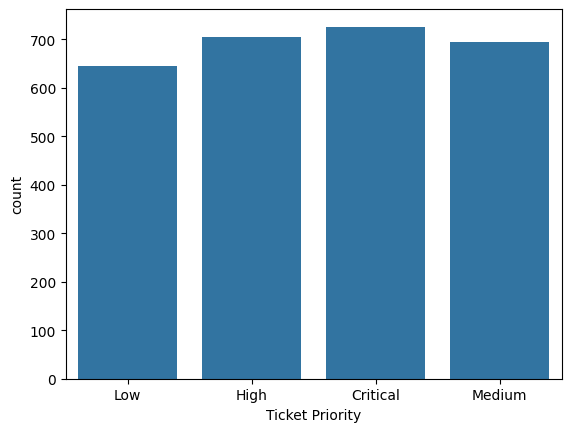

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Ticket Priority', data=df_ml)
plt.show()

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)
X_text = vectorizer.fit_transform(df_ml['Ticket Description'])

In [46]:
# Priority
y_priority = df_ml['Ticket Priority']

# Time (FIXED - convert timestamps to numerical durations)
# Convert 'Time to Resolution' to datetime objects, coercing errors to NaT
time_resolution_dt = pd.to_datetime(df_ml['Time to Resolution'], errors='coerce')

# Calculate the duration from the earliest resolution time in seconds
# This converts absolute timestamps into relative durations
y_time = (time_resolution_dt - time_resolution_dt.min()).dt.total_seconds()


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_pr_train, y_pr_test, y_time_train, y_time_test = train_test_split(
    X_text, y_priority, y_time, test_size=0.2, random_state=42
)

In [48]:
# Model 1
from sklearn.linear_model import LogisticRegression

model_priority = LogisticRegression(max_iter=200)
model_priority.fit(X_train, y_pr_train)

LogisticRegression(max_iter=200)

In [49]:
# Model 2
from sklearn.linear_model import LinearRegression

model_time = LinearRegression()
model_time.fit(X_train, y_time_train)

LinearRegression()

In [50]:
from sklearn.metrics import accuracy_score, mean_absolute_error

# Priority
pred_pr = model_priority.predict(X_test)
print("Priority Accuracy:", accuracy_score(y_pr_test, pred_pr))

# Time
pred_time = model_time.predict(X_test)
print("MAE (seconds):", mean_absolute_error(y_time_test, pred_time))

Priority Accuracy: 0.2743682310469314
MAE (seconds): 537770.5405464965


In [51]:
# RAG set up

kb = df_rag[['Ticket Description', 'Resolution']].sample(2000).reset_index(drop=True)

In [52]:
from sentence_transformers import SentenceTransformer
import numpy as np

embed_model=SentenceTransformer('all-MiniLM-L6-V2')
kb_embeddings = embed_model.encode(kb['Ticket Description'].tolist(),show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

In [56]:
# FAISS INDEX

#!pip install faiss-cpu
import faiss
dimension = kb_embeddings.shape[1]
index=faiss.IndexFlatL2(dimension)
index.add(np.array(kb_embeddings))

In [71]:

# Retrival Function

def retrieve_similar(query,k=3):
  q_embed=embed_model.encode([query])
  distances,indices = index.search(np.array(q_embed),k)

  result=[]
  for i in indices[0]:
    result.append({
        'issue': kb.iloc[i]['Ticket Description'],
        'solution':kb.iloc[i]['Resolution']
        })
    return result

In [77]:

# LLM Response

from openai import OpenAI
client=OpenAI(api_key='API key')

def generate_respone(query):
  retrieved = retrieve_similar(query)

  context=''
  for item in retrieved:
    context+=f'Issue: {item['issue']}\nSolution: {item['solution']}\n\n'
    prompt = f"""
    You are a professional customer support assistant.

    Use the past resolved tickets below:

    {context}

    Customer Query: {query}

    Give a clear and helpful response.
    """

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}]
    )

    return response.choices[0].message.content


In [78]:
def seconds_to_days(sec):
    return sec / (60*60*24)

def full_pipeline(query):
    vec = vectorizer.transform([query])

    # ML
    priority = model_priority.predict(vec)[0]
    time_sec = model_time.predict(vec)[0]

    # GenAI
    response = generate_response(query)

    return {
        "Predicted Priority": priority,
        "Estimated Resolution (days)": round(seconds_to_days(time_sec), 2),
        "AI Response": response
    }

In [79]:
# Test Demo

query = "My product is not working after setup"

result = full_pipeline(query)

print(result)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: API key. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}